### Imports

In [1]:
from datetime import date
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Define timeframe for stock data (5 years)

In [2]:
end = date.today()
start = end.replace(
    year=end.year - 5,
    day = min(end.day, 28) if end.month == 2 else end.day
)

start_date = start.strftime("%Y-%m-%d")
end_date = end.strftime("%Y-%m-%d")

### Fetch and clean stock data

In [3]:
def get_stock_data(ticker):
    data = yf.download(ticker, start_date, end_date)
    return data

df = get_stock_data("AAPL")
df.reset_index(inplace=True)
df.columns = df.columns.get_level_values(0)
df.columns.name = None
df.head()

[*********************100%***********************]  1 of 1 completed


,Date,Close,High,Low,Open,Volume
0,2021-03-29,118.233322,119.392379,117.590489,118.486563,80819200
1,2021-03-30,116.782059,117.269056,115.769103,116.986597,85671900
2,2021-03-31,118.973557,120.307926,117.999561,118.486559,118323800
3,2021-04-01,119.801453,120.950768,119.304713,120.444293,75089100
4,2021-04-05,122.626045,122.879286,119.869636,120.648835,88651200


### Plot stock data

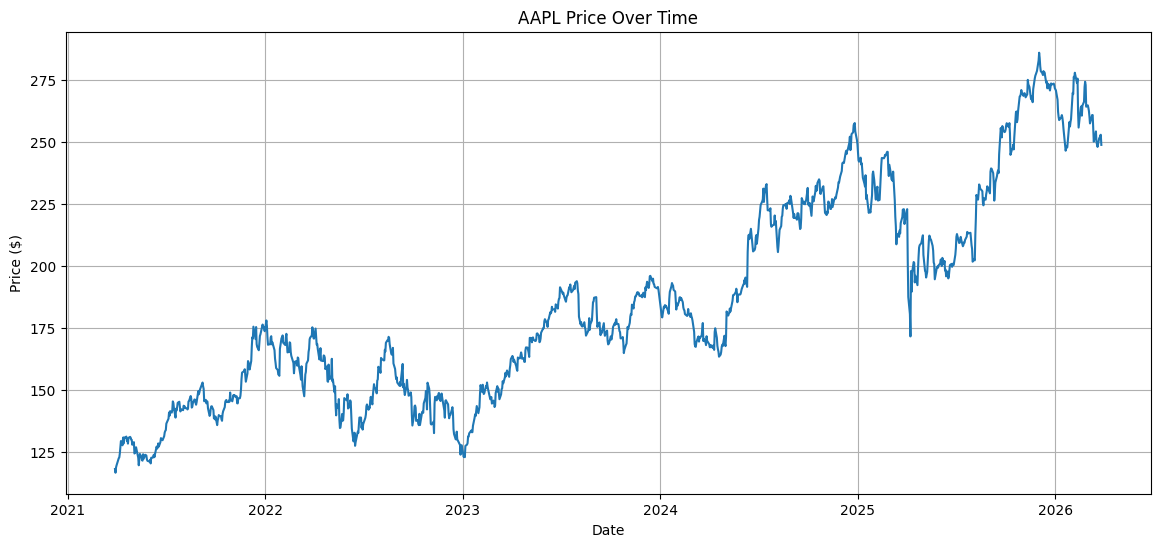

In [4]:
plt.figure(figsize=(14, 6))
plt.grid(True)
plt.plot(df["Date"], df["Close"])
plt.xlabel("Date")
plt.ylabel("Price ($)")
plt.title("AAPL Price Over Time")
plt.show()

### Plot the 9, 21, and 100 EMAs

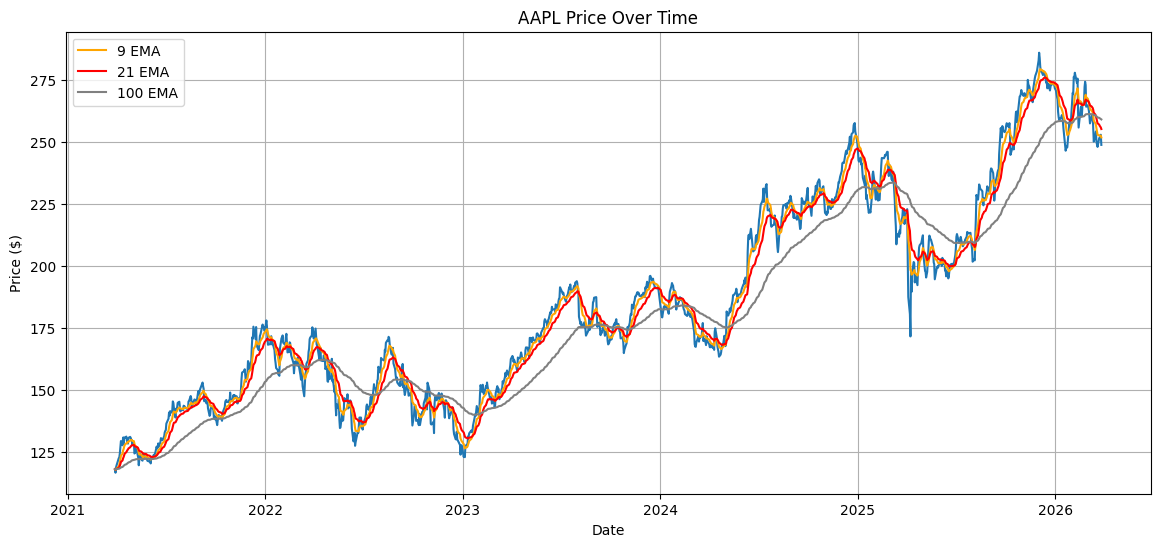

In [5]:
# Calculate EMAs
df["ema9"] = df["Close"].ewm(span=9, adjust=False).mean()
df["ema21"] = df["Close"].ewm(span=21, adjust=False).mean()
df["ema100"] = df["Close"].ewm(span=100, adjust=False).mean()

# Plot price
plt.figure(figsize=(14, 6))
plt.grid(True)
plt.plot(df["Date"], df["Close"])
plt.xlabel("Date")
plt.ylabel("Price ($)")
plt.title("AAPL Price Over Time")

# Plot EMAs
plt.plot(df["Date"], df["ema9"], label="9 EMA", color="orange")
plt.plot(df["Date"], df["ema21"], label="21 EMA", color="red")
plt.plot(df["Date"], df["ema100"], label="100 EMA", color="gray")
plt.legend()

### Create 21 EMA distance, 21 EMA slope, and daily % return features

In [6]:
df["dist_ema21"] = (df["Close"] - df["ema21"]) / df["ema21"]
df["slope_ema21"] = df["ema21"].diff()
df["return"] = df["Close"].pct_change()
df.head()

,Date,Close,High,Low,Open,Volume,ema9,ema21,ema100,dist_ema21,slope_ema21,return
0,2021-03-29,118.233322,119.392379,117.590489,118.486563,80819200,118.233322,118.233322,118.233322,0.000000,NaN,NaN
1,2021-03-30,116.782059,117.269056,115.769103,116.986597,85671900,117.943069,118.101389,118.204584,-0.011171,-0.131933,-0.012275
2,2021-03-31,118.973557,120.307926,117.999561,118.486559,118323800,118.149167,118.180677,118.219811,0.006709,0.079288,0.018766
3,2021-04-01,119.801453,120.950768,119.304713,120.444293,75089100,118.479624,118.328020,118.251131,0.012452,0.147343,0.006959
4,2021-04-05,122.626045,122.879286,119.869636,120.648835,88651200,119.308908,118.718750,118.337763,0.032912,0.390730,0.023577


In [7]:
df = df.dropna().reset_index(drop=True)
df.drop(columns=["High", "Low", "Open", "Volume"], inplace=True)
df.head()

,Date,Close,ema9,ema21,ema100,dist_ema21,slope_ema21,return
0,2021-03-30,116.782059,117.943069,118.101389,118.204584,-0.011171,-0.131933,-0.012275
1,2021-03-31,118.973557,118.149167,118.180677,118.219811,0.006709,0.079288,0.018766
2,2021-04-01,119.801453,118.479624,118.328020,118.251131,0.012452,0.147343,0.006959
3,2021-04-05,122.626045,119.308908,118.718750,118.337763,0.032912,0.390730,0.023577
4,2021-04-06,122.928001,120.032727,119.101409,118.428659,0.032129,0.382659,0.002462


### Use a 70/15/15 train/validation/test split

In [8]:
df.shape

(1255, 8)

In [9]:
train_end = int(len(df) * 0.7)
val_end = int(len(df) * 0.85)

train = df[:train_end]
val = df[train_end:val_end]
test = df[val_end:]

In [10]:
print(train.shape)
train.head()

(878, 8)


,Date,Close,ema9,ema21,ema100,dist_ema21,slope_ema21,return
0,2021-03-30,116.782059,117.943069,118.101389,118.204584,-0.011171,-0.131933,-0.012275
1,2021-03-31,118.973557,118.149167,118.180677,118.219811,0.006709,0.079288,0.018766
2,2021-04-01,119.801453,118.479624,118.328020,118.251131,0.012452,0.147343,0.006959
3,2021-04-05,122.626045,119.308908,118.718750,118.337763,0.032912,0.390730,0.023577
4,2021-04-06,122.928001,120.032727,119.101409,118.428659,0.032129,0.382659,0.002462


In [11]:
print(val.shape)
val.head()

(188, 8)


,Date,Close,ema9,ema21,ema100,dist_ema21,slope_ema21,return
878,2024-09-25,224.892700,223.540170,222.341681,211.404975,0.011473,0.255102,-0.004398
879,2024-09-26,226.035202,224.039176,222.677456,211.694682,0.015079,0.335775,0.005080
880,2024-09-27,226.303436,224.492028,223.007090,211.983965,0.014781,0.329635,0.001187
881,2024-09-30,231.479446,225.889512,223.777305,212.370014,0.034419,0.770214,0.022872
882,2024-10-01,224.733765,225.658362,223.864255,212.614841,0.003884,0.086951,-0.029142


In [12]:
print(test.shape)
test.head()

(189, 8)


,Date,Close,ema9,ema21,ema100,dist_ema21,slope_ema21,return
1066,2025-06-27,200.469971,199.791319,200.129109,209.377173,0.001703,0.034086,0.000398
1067,2025-06-30,204.547531,200.742562,200.530784,209.281536,0.020031,0.401675,0.020340
1068,2025-07-01,207.189514,202.031952,201.136123,209.240110,0.030096,0.605339,0.012916
1069,2025-07-02,211.795486,203.984659,202.105156,209.290711,0.047947,0.969033,0.022231
1070,2025-07-03,212.902115,205.768150,203.086698,209.362224,0.048331,0.981542,0.005225


### Normalize the dataset

In [13]:
from sklearn.preprocessing import MinMaxScaler

In [14]:
features = ["Close", "ema21", "dist_ema21", "slope_ema21", "return"]
target = "Close"

# MinMaxScaler has default param feature_range=(0,1)
features_scaler = MinMaxScaler()
target_scaler = MinMaxScaler()

# Training data
train_features = train[features]
train_target = train[[target]]

# Validation data
val_features = val[features]
val_target = val[[target]]

# Testing data
test_features = test[features]
test_target = test[[target]]

# Scale training data
train_features_scaled = features_scaler.fit_transform(train_features)
train_target_scaled = target_scaler.fit_transform(train_target)

window = 20

# Scale validation data
prev_window_val = train_features.tail(window)
val_features = pd.concat([prev_window_val, val_features], ignore_index=True)
val_features_scaled = features_scaler.transform(val_features)
val_target_scaled = target_scaler.transform(val_target)

# Scale testing data
# We take data from val_features (and not train_features) because data needs to stay chronological
prev_window_test = val_features.tail(window)
test_features = pd.concat([prev_window_test, test_features], ignore_index=True)
test_features_scaled = features_scaler.transform(test_features)
test_target_scaled = target_scaler.transform(test_target)

print(train_features_scaled.shape)
print(val_features_scaled.shape)
print(test_features_scaled.shape)

print(train_target_scaled.shape)
print(val_target_scaled.shape)
print(test_target_scaled.shape)

(878, 5)
(208, 5)
(209, 5)
(878, 1)
(188, 1)
(189, 1)


In [15]:
print(train_features_scaled[:3])
print(train_features_scaled[-3:])

[[0.         0.         0.44159075 0.40206584 0.31428236]
 [0.0188539  0.00075791 0.53073719 0.46312117 0.52450546]
 [0.02597646 0.00216635 0.55937068 0.48279316 0.44454115]]
[[0.94573888 0.98721168 0.61738727 0.59434816 0.37758656]
 [0.93095252 0.99035219 0.5711706  0.53517063 0.3460697 ]
 [0.93864494 0.9939842  0.58258721 0.55003329 0.42432777]]


In [16]:
print(test_features_scaled[:3])
print(test_features_scaled[-3:])

[[0.71029171 0.81178283 0.4068602  0.33376207 0.38152999]
 [0.7180113  0.80936268 0.43503513 0.3670176  0.42789809]
 [0.72530176 0.80789894 0.45960791 0.39593913 0.4260744 ]]
[[1.16864134 1.31942225 0.42892179 0.33868089 0.42378843]
 [1.17096424 1.31660487 0.43984875 0.3550053  0.40465166]
 [1.13577717 1.31048944 0.37229803 0.25527318 0.28787973]]


In [17]:
print(train_target_scaled[:3])
print(train_target_scaled[-3:])

[[0.        ]
 [0.0188539 ]
 [0.02597646]]
[[0.94573888]
 [0.93095252]
 [0.93864494]]


In [18]:
print(test_target_scaled[:3])
print(test_target_scaled[-3:])

[[0.71998409]
 [0.75506417]
 [0.77779369]]
[[1.16864134]
 [1.17096424]
 [1.13577717]]


### Create training sequences

In [19]:
x_train = []
y_train = []

# For each timestamp (row) x, grab the #(window) timestamps before it and add them as a singular element to x_train. Add timestamp x as an element to y_train.
for i in range(window, train_features_scaled.shape[0]):
    x_train.append(train_features_scaled[i - window : i])
    y_train.append(train_target_scaled[i, 0])

x_train = np.array(x_train)
y_train = np.array(y_train)

print(x_train.shape)
print(y_train.shape)

(858, 20, 5)
(858,)


### Create validation sequences

In [20]:
x_val = []
y_val = []

for i in range(window, val_features_scaled.shape[0]):
    x_val.append(val_features_scaled[i - window : i])
    y_val.append(val_target_scaled[i - window, 0])

x_val = np.array(x_val)
y_val = np.array(y_val)

print(x_val.shape)
print(y_val.shape)

(188, 20, 5)
(188,)


### Create testing sequences

In [21]:
x_test = []
y_test = []

for i in range(window, test_features_scaled.shape[0]):
    x_test.append(test_features_scaled[i - window : i])
    y_test.append(test_target_scaled[i - window, 0])

x_test = np.array(x_test)
y_test = np.array(y_test)

print(x_test.shape)
print(y_test.shape)

(189, 20, 5)
(189,)


### Build LSTM model

In [22]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dropout, Dense

In [23]:
model = Sequential()

model.add(Input(shape=(x_train.shape[1], x_train.shape[2])))

model.add(LSTM(units=64, return_sequences=True))
model.add(Dropout(0.1))

model.add(LSTM(units=32))
model.add(Dropout(0.1))

model.add(Dense(units=1))

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 20, 64)         │        17,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 20, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,369 (118.63 KB)

 Trainable params: 30,369 (118.63 KB)

 Non-trainable params: 0 (0.00 B)

### Train model

In [24]:
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping

In [25]:
model.compile(
    optimizer="adam",
    loss=tf.keras.losses.Huber(),
    metrics=[tf.keras.metrics.MeanAbsoluteError()]
)

early_stopping = EarlyStopping(monitor="val_loss", patience=25, restore_best_weights=True)

history = model.fit(x_train, y_train, epochs=100, validation_data=(x_val, y_val), shuffle=False, callbacks=[early_stopping])

Epoch 1/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 0.0199 - mean_absolute_error: 0.1530 - val_loss: 0.0059 - val_mean_absolute_error: 0.0910
Epoch 2/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0373 - mean_absolute_error: 0.2254 - val_loss: 0.0278 - val_mean_absolute_error: 0.2161
Epoch 3/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0092 - mean_absolute_error: 0.1144 - val_loss: 0.0066 - val_mean_absolute_error: 0.0932
Epoch 4/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0038 - mean_absolute_error: 0.0690 - val_loss: 0.0034 - val_mean_absolute_error: 0.0601
Epoch 5/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0026 - mean_absolute_error: 0.0570 - val_loss: 0.0029 - val_mean_absolute_error: 0.0563
Epoch 6/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0021 - mean_absolute_error: 0.0503 - val_loss: 0.0027 - val_mean_absolute_error: 0.0535
Epoch 7/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0018 - mean_absolute_error: 0.0483 - v

### Plot loss curves

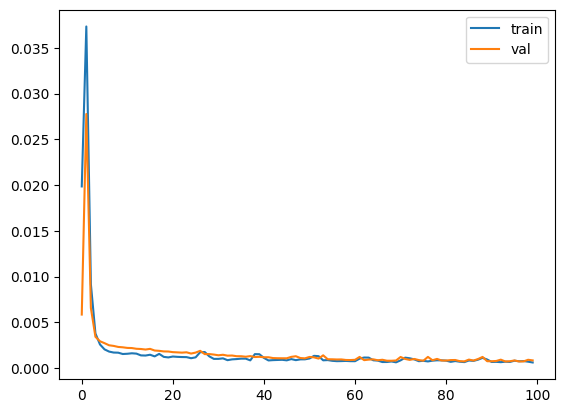

In [26]:
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="val")
plt.legend()

### Make prediction

In [27]:
y_pred = model.predict(x_test)
print(y_pred.shape)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
(189, 1)


In [28]:
print(y_test[:10])

[0.71998409 0.75506417 0.77779369 0.81741981 0.82694035 0.7960629
 0.79657736 0.80626962 0.81716251 0.80644119]


In [29]:
print(y_pred[:10])

[[0.7224441 ]
 [0.7231906 ]
 [0.75734097]
 [0.7814887 ]
 [0.8209667 ]
 [0.83039016]
 [0.8006851 ]
 [0.8010809 ]
 [0.8123769 ]
 [0.8247921 ]]


### Plot prediction

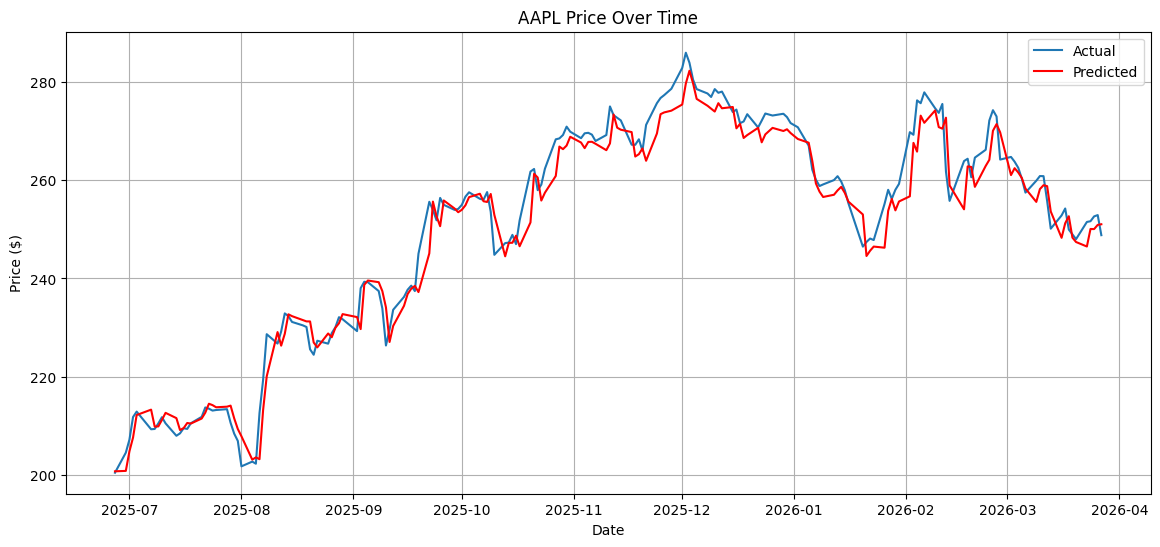

In [30]:
y_pred_prices = target_scaler.inverse_transform(y_pred).flatten()
y_test_prices = target_scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

# Plot price
plt.figure(figsize=(14, 6))
plt.grid(True)
plt.plot(test["Date"], y_test_prices, label="Actual")
plt.plot(test["Date"], y_pred_prices, label="Predicted", color="red")
plt.xlabel("Date")
plt.ylabel("Price ($)")
plt.title("AAPL Price Over Time")
plt.legend()